<a href="https://colab.research.google.com/github/ecloguehwang/schoolconsulting/blob/main/4%ED%95%99%EA%B8%B0%EB%82%B4%EC%8B%A0%EB%B3%80%ED%99%94_2026%EA%B3%A03_%EC%88%98%EB%AA%85%EA%B3%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#colab에서 matplotlib와 sns 라이브러리 그래프 한글을 깨지지 않게 하는 법: 실행하고 런타임 재시작
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (51.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [ ]:
# 전처리

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

# 그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 데이터 부르기
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'
df_raw = pd.read_excel(f'{path}nesin_4semesters_sumyeong2026.xlsx', header=[0, 1, 2])



# 멀티레벨 컬럼 평탄화 (Unnamed 제거하고 실제 이름만 남기기)
def clean_col(col):
    parts = [str(c).strip() for c in col if 'Unnamed' not in str(c) and str(c).strip() != '']
    return '_'.join(parts) if parts else 'unknown'

df_raw.columns = [clean_col(c) for c in df_raw.columns]

# 실제 컬럼 이름 확인
print(df_raw.columns.tolist())

# 컬럼 이름 매핑 (인덱스 15→'삼학년_전학기', 16→'전학년' 으로 수정)
col_map = {
    df_raw.columns[0]:  '계열',
    df_raw.columns[1]:  '학년',
    df_raw.columns[2]:  '반',
    df_raw.columns[3]:  '번호',
    df_raw.columns[4]:  '이름',
    df_raw.columns[5]:  '석차',
    df_raw.columns[6]:  '석차백분율',
    df_raw.columns[7]:  '일학년_1학기',
    df_raw.columns[8]:  '일학년_2학기',
    df_raw.columns[9]:  '일학년_전학기',
    df_raw.columns[10]: '이학년_1학기',
    df_raw.columns[11]: '이학년_2학기',
    df_raw.columns[12]: '이학년_전학기',
    df_raw.columns[13]: '삼학년_1학기',
    df_raw.columns[14]: '삼학년_2학기',
    df_raw.columns[15]: '삼학년_전학기',  # ← 수정
    df_raw.columns[16]: '전학년',          # ← 수정 (인덱스 16)
}

df = df_raw.rename(columns=col_map)

# 병합 셀로 인한 NaN을 ffill로 채우기
text_cols = ['계열', '학년', '반', '번호', '이름']
df[text_cols] = df[text_cols].ffill()

# '계열', '삼학년_1학기', '삼학년_2학기', '삼학년_전학기' 열 삭제
df = df.drop(columns=['계열', '삼학년_1학기', '삼학년_2학기', '삼학년_전학기'])

# 학기별 숫자 열 목록
semester_cols = ['일학년_1학기', '일학년_2학기', '일학년_전학기',
                 '이학년_1학기', '이학년_2학기', '이학년_전학기']

# '전학기' 제외하고 순수 학기(1학기/2학기)만 카운트
score_cols = [c for c in semester_cols if '전학기' not in c]
n = len(score_cols)

# '전학년' 열 이름을 동적으로 변경
nesin_col = f'내신_{n}개학기'
df = df.rename(columns={'전학년': nesin_col})

# 최종 컬럼 순서 정리
final_cols = ['학년', '반', '번호', '이름',
              '석차', '석차백분율',
              '일학년_1학기', '일학년_2학기', '일학년_전학기',
              '이학년_1학기', '이학년_2학기', '이학년_전학기',
              nesin_col]

df = df[final_cols]

# 숫자 컬럼 '-' → NaN 변환 후 숫자형으로 변환
numeric_cols = score_cols + ['일학년_전학기', '이학년_전학기',
                             '석차', '석차백분율', nesin_col]

df[numeric_cols] = df[numeric_cols].apply(
    lambda col: pd.to_numeric(col.mask(col == '-'), errors='coerce')
)

# 결측 행(이름 없는 행) 제거
df = df.dropna(subset=['이름'])

print(f"▶ 내신 열 이름: '{nesin_col}' ({n}개 학기 기준)")
print(f"▶ 전처리 후 행 수: {len(df)}")

df.head()

## 결과 저장
output_filename = 'nesin_4semesters_sumyeong2026_cleaning.xlsx'
output_path = f'{path}{output_filename}'
df.to_excel(output_path, index=False)
print(f"▶ 저장 완료: {output_path}")

['계열', '학년', '반', '번호', '이름', '석차등급_석차', '석차등급_석차백분율', '석차등급_1학년_1학기', '석차등급_1학년_2학기', '석차등급_1학년_전학기', '석차등급_2학년_1학기', '석차등급_2학년_2학기', '석차등급_2학년_전학기', '석차등급_3학년_1학기', '석차등급_3학년_2학기', '석차등급_3학년_전학기', '석차등급_전학년']
▶ 내신 열 이름: '내신_4개학기' (4개 학기 기준)
▶ 전처리 후 행 수: 195
▶ 저장 완료: /content/drive/MyDrive/python/sumyeong/2026/nesin/nesin_4semesters_sumyeong2026_cleaning.xlsx


In [2]:
#전처리된 파일 불러오기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate


# matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

# 그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



## 경로에서 데이터 부르기
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'
df = pd.read_excel(f'{path}nesin_4semesters_sumyeong2026_cleaning.xlsx')

df.head(10)

,학년,반,번호,이름,석차,석차백분율,일학년_1학기,일학년_2학기,일학년_전학기,이학년_1학기,이학년_2학기,이학년_전학기,내신_4개학기
0,3,6,27,최완서,1,0.51,1.00,1.17,1.08,1.26,1.61,1.43,1.26
1,3,2,27,정다경,2,1.03,1.46,1.17,1.31,1.13,1.30,1.22,1.27
2,3,3,10,김효원,3,1.54,1.29,1.17,1.23,1.48,1.78,1.63,1.43
3,3,2,26,정건하,4,2.05,1.54,1.46,1.50,1.52,1.91,1.72,1.61
4,3,2,14,오승화,5,2.56,1.08,1.25,1.17,2.48,1.91,2.20,1.67
5,3,4,31,한준우,6,3.08,1.83,1.50,1.67,2.09,1.83,1.96,1.81
6,3,2,11,심재원,7,3.59,1.75,1.71,1.73,2.09,2.22,2.15,1.94
7,3,5,2,김도담,7,3.59,2.13,1.67,1.90,2.04,1.91,1.98,1.94
8,3,2,30,정하은,9,4.62,1.96,1.79,1.88,2.17,2.43,2.30,2.09
9,3,1,26,조민석,10,5.13,2.79,1.75,2.27,2.35,1.65,2.00,2.14


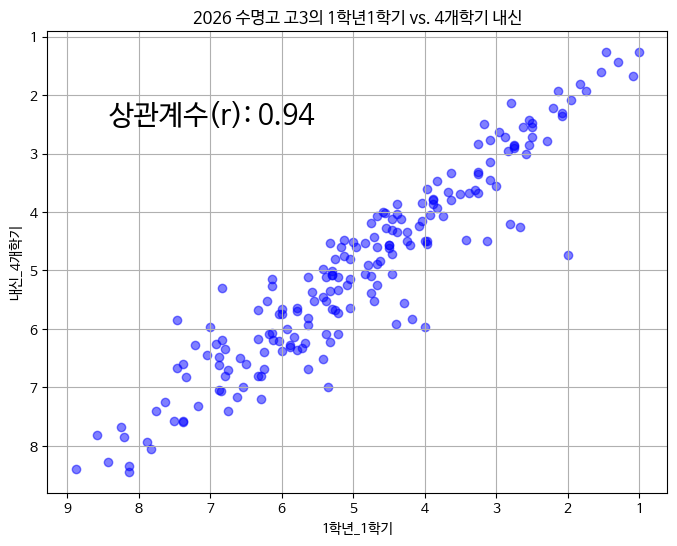

In [ ]:
#1. 1학년 1학기 내신과 4개학기 내신의 상관관계


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate


# matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

# 그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



## 경로에서 데이터 부르기
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'
df = pd.read_excel(f'{path}nesin_4semesters_sumyeong2026_cleaning.xlsx')



# 산점도(scatter plot) 생성, x축과 y축 반전
plt.figure(figsize=(8, 6))
plt.scatter(df['일학년_1학기'], df['내신_4개학기'], color='blue', alpha=0.5)


# 상관계수 계산
# ✅ NaN 제거 후 상관계수 계산
valid = df[['일학년_1학기', '내신_4개학기']].dropna()
corr = np.corrcoef(valid['일학년_1학기'], valid['내신_4개학기'])[0, 1]

# 상관계수를 그래프에 표시
plt.text(0.1, 0.80, f'상관계수(r): {corr:.2f}', transform=plt.gca().transAxes, fontsize=20)

plt.title("2026 수명고 고3의 1학년1학기 vs. 4개학기 내신")
plt.xlabel("1학년_1학기")
plt.ylabel("내신_4개학기")
plt.gca().invert_xaxis()  # x축 방향 반전
plt.gca().invert_yaxis()  # y축 방향 반전

plt.grid(True)
plt.show()

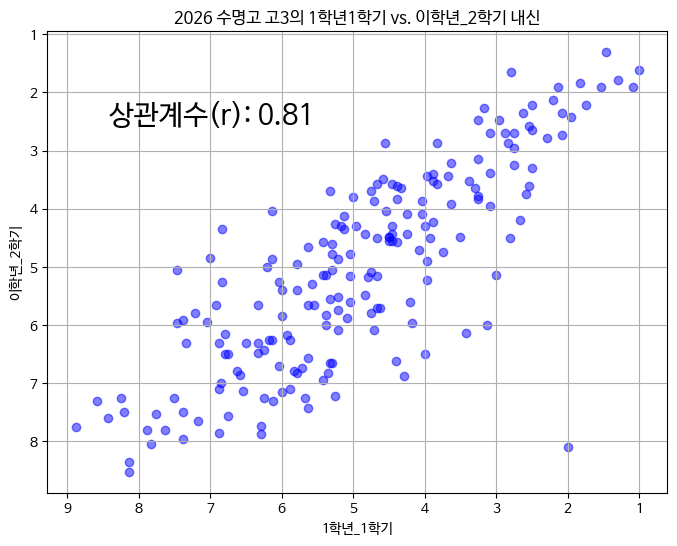

In [ ]:
#그래프 2: 상관관계 - 1학년 1학기 내신과 2학년 2학기 내신

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# 산점도(scatter plot) 생성, x축과 y축 반전
plt.figure(figsize=(8, 6))
plt.scatter(df['일학년_1학기'], df['이학년_2학기'], color='blue', alpha=0.5)


# 상관계수 계산
# ✅ NaN 제거 후 상관계수 계산
valid = df[['일학년_1학기', '이학년_2학기']].dropna()
corr = np.corrcoef(valid['일학년_1학기'], valid['이학년_2학기'])[0, 1]

# 상관계수를 그래프에 표시
plt.text(0.1, 0.80, f'상관계수(r): {corr:.2f}', transform=plt.gca().transAxes, fontsize=20)

plt.title("2026 수명고 고3의 1학년1학기 vs. 이학년_2학기 내신")
plt.xlabel("1학년_1학기")
plt.ylabel("이학년_2학기")
plt.gca().invert_xaxis()  # x축 방향 반전
plt.gca().invert_yaxis()  # y축 방향 반전

plt.grid(True)
plt.show()


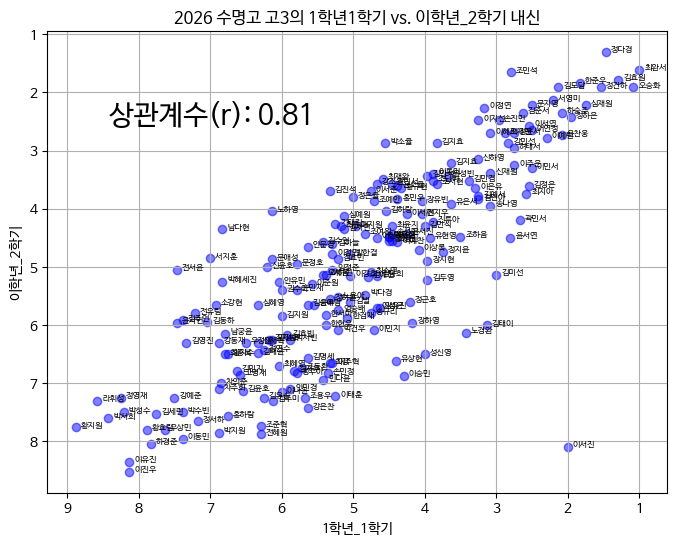

In [ ]:
#그래프 3: 1학년 1학기 내신과 2학년 2학기 내신의 상관관계

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 산점도(scatter plot) 생성, x축과 y축 반전
plt.figure(figsize=(8, 6))
plt.scatter(df['일학년_1학기'], df['이학년_2학기'], color='blue', alpha=0.5)

# ✅ 각 점에 이름 표시
for i in range(len(df)):
    plt.text(df['일학년_1학기'][i]-0.07, df['이학년_2학기'][i], df['이름'][i], fontsize=6)

# ✅ NaN 제거 후 상관계수 계산
valid = df[['일학년_1학기', '이학년_2학기']].dropna()
corr = np.corrcoef(valid['일학년_1학기'], valid['이학년_2학기'])[0, 1]

# 상관계수를 그래프에 표시
plt.text(0.1, 0.80, f'상관계수(r): {corr:.2f}', transform=plt.gca().transAxes, fontsize=20)

plt.title("2026 수명고 고3의 1학년1학기 vs. 이학년_2학기 내신")
plt.xlabel("1학년_1학기")
plt.ylabel("이학년_2학기")
plt.gca().invert_xaxis()  # x축 방향 반전
plt.gca().invert_yaxis()  # y축 방향 반전

plt.grid(True)
plt.show()

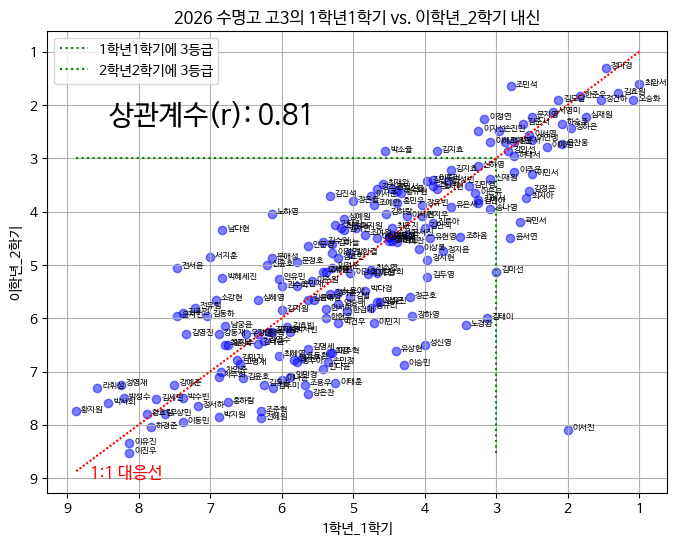

In [ ]:
#1:1 직선 추가 - 그래프 4: 1학년 1학기 내신과 2학년 2학기 내신의 상관관계

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 산점도(scatter plot) 생성, x축과 y축 반전
plt.figure(figsize=(8, 6))
plt.scatter(df['일학년_1학기'], df['이학년_2학기'], color='blue', alpha=0.5)

# 각 점에 이름 표시
for i in range(len(df)):
    plt.text(df['일학년_1학기'][i]-0.07, df['이학년_2학기'][i], df['이름'][i], fontsize=6)

# NaN 제거 후 상관계수 계산
valid = df[['일학년_1학기', '이학년_2학기']].dropna()
corr = np.corrcoef(valid['일학년_1학기'], valid['이학년_2학기'])[0, 1]

# 상관계수를 그래프에 표시
plt.text(0.1, 0.80, f'상관계수(r): {corr:.2f}', transform=plt.gca().transAxes, fontsize=20)

# ✅ 3등급 기준선 추가
x = valid['일학년_1학기']
y = valid['이학년_2학기']

# x=3 기준 수평선 (좌측 끝 ~ 교차점)
plt.plot([max(x), 3], [3, 3], color='green', linestyle=':', linewidth=1.5, label='1학년1학기에 3등급')

# y=3 기준 수직선 (상단 끝 ~ 교차점)
plt.plot([3, 3], [max(y), 3], color='green', linestyle=':', linewidth=1.5, label='2학년2학기에 3등급')

# 1:1 대응 직선 추가
min_val = min(x)
max_val = max(x)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', dashes=[1, 1])
plt.text(max_val- 0.2, max_val + 0.2, '1:1 대응선', color='red', verticalalignment='bottom', fontsize= 12)

plt.title("2026 수명고 고3의 1학년1학기 vs. 이학년_2학기 내신")
plt.xlabel("1학년_1학기")
plt.ylabel("이학년_2학기")
plt.gca().invert_xaxis()  # x축 방향 반전
plt.gca().invert_yaxis()  # y축 방향 반전

plt.legend()
plt.grid(True)
plt.show()

=== 이상치 행 ===
 이름  일학년_1학기  이학년_2학기
이서진      2.0     8.09


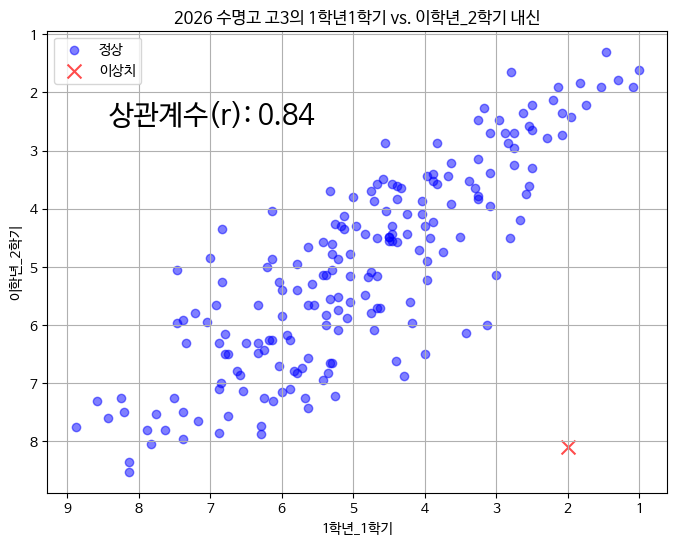

In [ ]:
#그래프 5: 자동 이상치 제거

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ NaN 제거
valid = df[['이름', '일학년_1학기', '이학년_2학기']].dropna()

# ✅ 이상치 탐지: 두 컬럼 값의 차이가 4 이상이면 이상치
outlier_mask = abs(valid['일학년_1학기'] - valid['이학년_2학기']) >= 4

# ✅ 이상치 / 정상 데이터 분리
outliers = valid[outlier_mask]
clean = valid[~outlier_mask].reset_index(drop=True)

# ✅ 이상치 출력
print("=== 이상치 행 ===")
print(outliers.to_string(index=False))

# 산점도 생성
plt.figure(figsize=(8, 6))
plt.scatter(clean['일학년_1학기'], clean['이학년_2학기'], color='blue', alpha=0.5, label='정상')
plt.scatter(outliers['일학년_1학기'], outliers['이학년_2학기'], color='red', alpha=0.7, marker='x', s=100, label='이상치')

# 상관계수 계산 (이상치 제외)
corr = np.corrcoef(clean['일학년_1학기'], clean['이학년_2학기'])[0, 1]

# 상관계수 표시
plt.text(0.1, 0.80, f'상관계수(r): {corr:.2f}', transform=plt.gca().transAxes, fontsize=20)

plt.title("2026 수명고 고3의 1학년1학기 vs. 이학년_2학기 내신")
plt.xlabel("1학년_1학기")
plt.ylabel("이학년_2학기")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.show()

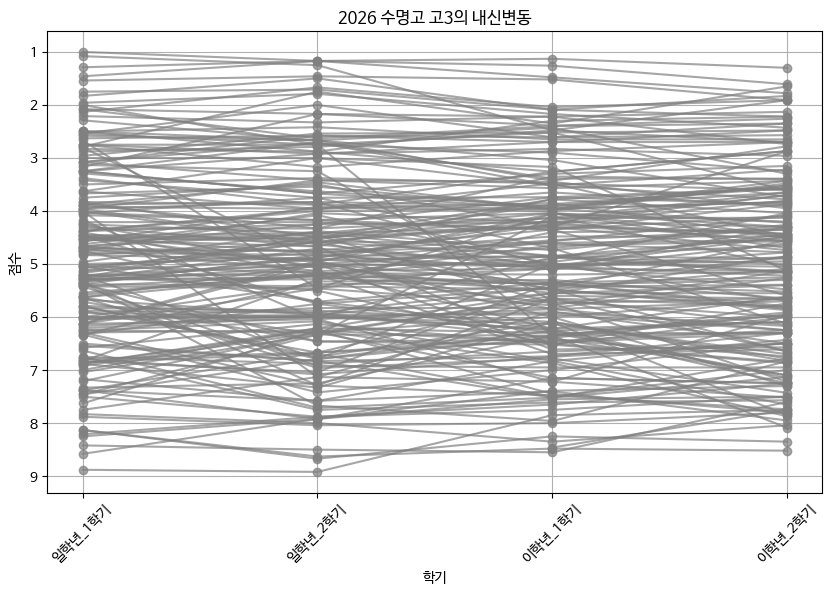

In [ ]:
#그래프 6: 1학년1학기부터 2학년2학기까지 내신변화

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 필요한 열만 추출 ('3학년_2학기' 제외)

x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']

df_selected = df[x_labels]

# '-'를 NaN으로 변환하고, 숫자로 변환할 수 있도록 처리
df_selected = df_selected.replace('-', np.nan).apply(pd.to_numeric, errors='coerce')

# X축 데이터 준비: 학기별 순서
x = x_labels

# 그래프 그리기
plt.figure(figsize=(10, 6))

# 각 학기 데이터를 시계열 형태로 플롯
for i, row in df_selected.iterrows():
    plt.plot(x, row, marker='o', linestyle='-', alpha=0.7, color='gray')  # 각 학생의 데이터를 선과 점으로 표시

# Y축 반전
plt.gca().invert_yaxis()

plt.title("2026 수명고 고3의 내신변동")
plt.xlabel("학기")
plt.ylabel("점수")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

전체 분석 대상 학생 수: 195명
연속적으로 내신상승한 학생 수: 23명
연속적으로 내신상승한 학생 비율: 11.79%

연속적으로 내신이 상승한 학생들의 점수 변화:
------------------------------------------------------------
학생 19: [2.96 2.54 2.52 2.48]
학생 24: [3.25 2.92 2.7  2.48]
학생 52: [4.55 4.5  4.3  2.87]
학생 53: [4.38 4.   3.96 3.83]
학생 55: [4.67 4.25 3.74 3.57]
학생 75: [5.   4.88 4.25 3.8 ]
학생 76: [5.33 4.88 4.17 3.7 ]
학생 88: [5.13 4.92 4.55 4.35]
학생 90: [5.25 5.   4.7  4.26]
학생 94: [5.42 5.21 4.65 4.57]
학생 99: [5.29 5.13 5.09 4.78]
학생 102: [5.63 5.21 4.85 4.65]
학생 105: [6.13 5.46 4.91 4.04]
학생 109: [6.83 5.29 4.4  4.35]
학생 129: [6.   5.96 5.55 5.4 ]
학생 136: [7.   6.21 5.55 4.85]
학생 149: [6.92 6.29 6.   5.65]
학생 162: [7.38 6.67 6.35 5.91]
학생 165: [7.46 6.79 6.39 5.96]
학생 172: [7.33 7.25 6.35 6.3 ]
학생 187: [8.58 7.92 7.39 7.3 ]
학생 188: [8.21 7.88 7.75 7.5 ]
학생 191: [8.46 7.75]


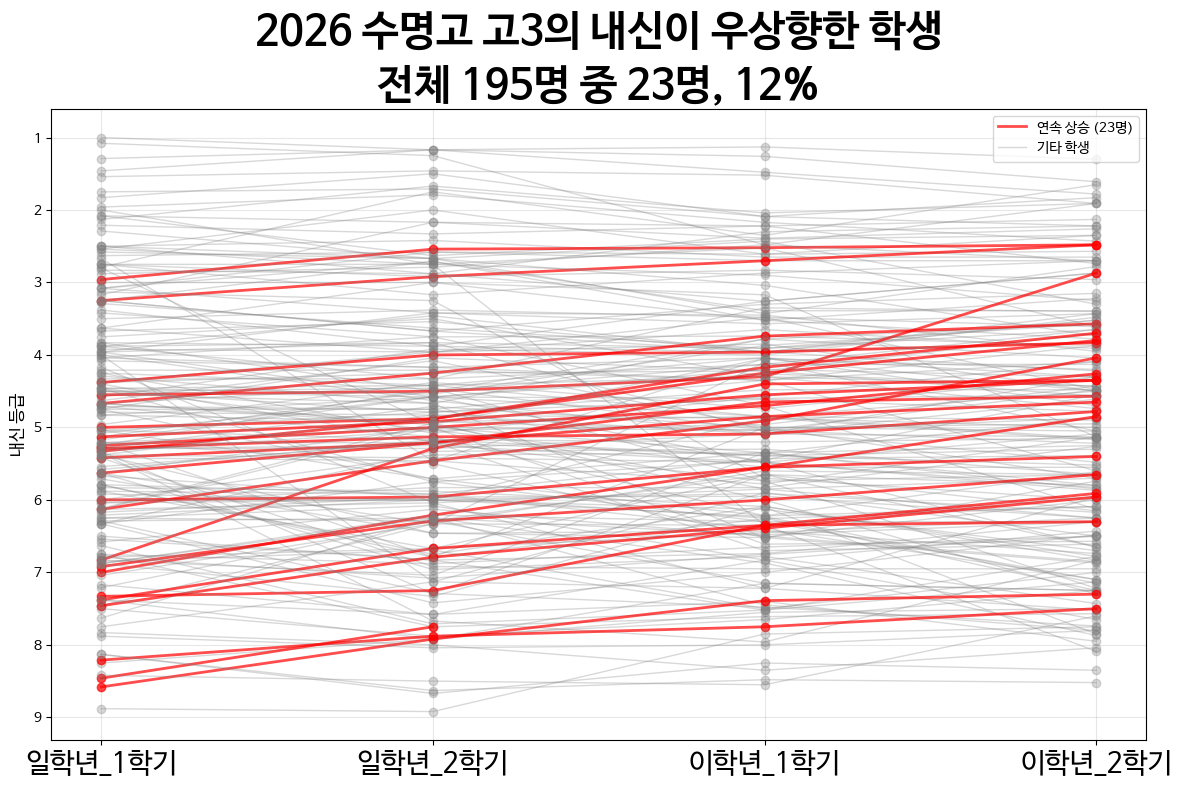


학기별 평균 내신 등급:
------------------------------
일학년_1학기: 4.91
일학년_2학기: 4.96
이학년_1학기: 5.01
이학년_2학기: 5.05


In [ ]:
#그래프 7: 내신 3개학기 우상향 학생

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 필요한 열만 추출 ('3학년_2학기' 제외)
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
df_selected = df[x_labels]


# '-'를 NaN으로 변환하고, 숫자로 변환할 수 있도록 처리
df_selected = df_selected.replace('-', np.nan).apply(pd.to_numeric, errors='coerce')


# 연속적으로 하락한 학생들을 찾기 위한 리스트
declining_students = []
total_valid_students = 0


# 각 학생별로 점수 변화 분석
for i, row in df_selected.iterrows():
    # NaN이 아닌 점수들만 추출
    valid_scores = row.dropna()

    # 최소 2개 이상의 점수가 있어야 비교 가능
    if len(valid_scores) >= 2:
        total_valid_students += 1

        # 연속으로 점수가 하락하는지 확인 (모든 차이가 음수인지)
        score_diffs = np.diff(valid_scores.values)
        is_continuously_declining = all(diff < 0 for diff in score_diffs)

        if is_continuously_declining:
            declining_students.append(i)

# 결과 계산
num_declining_students = len(declining_students)
declining_ratio = (num_declining_students / total_valid_students) * 100 if total_valid_students > 0 else 0

# 결과 출력
print(f"전체 분석 대상 학생 수: {total_valid_students}명")
print(f"연속적으로 내신상승한 학생 수: {num_declining_students}명")
print(f"연속적으로 내신상승한 학생 비율: {declining_ratio:.2f}%")

# 연속 하락 학생들의 상세 정보 출력
if num_declining_students > 0:
    print("\n연속적으로 내신이 상승한 학생들의 점수 변화:")
    print("-" * 60)
    for student_idx in declining_students:
        student_scores = df_selected.iloc[student_idx].dropna()
        print(f"학생 {student_idx + 1}: {student_scores.values}")

# 시각화
plt.figure(figsize=(12, 8))

# 각 학생별로 데이터를 시계열 형태로 플롯
for i, row in df_selected.iterrows():
    valid_scores = row.dropna()

    if len(valid_scores) >= 2:
        y = valid_scores.values
        x_positions = list(range(len(y)))
        x_semester_labels = [x_labels[j] for j in range(len(y))]

        # 연속으로 점수가 하락하는지 확인
        score_diffs = np.diff(y)
        is_continuously_declining = all(diff < 0 for diff in score_diffs)

        # 조건에 따라 컬러 또는 흑백으로 선 표시
        if is_continuously_declining:
            plt.plot(x_positions, y, marker='o', linestyle='-', color='red', alpha=0.7, linewidth=2)
        else:
            plt.plot(x_positions, y, marker='o', linestyle='-', color='gray', alpha=0.3, linewidth=1)

# Y축 반전 (내신은 숫자가 낮을수록 좋음)
plt.gca().invert_yaxis()

plt.title(f"2026 수명고 고3의 내신이 우상향한 학생\n전체 {total_valid_students}명 중 {num_declining_students}명, {declining_ratio:.0f}%",
          fontsize= 30, fontweight='bold')
#plt.xlabel("학기", fontsize=12)
plt.ylabel("내신 등급", fontsize=12)
plt.grid(True, alpha=0.3)

# x축 레이블 설정
plt.xticks(range(len(x_labels)), x_labels, rotation= 0, fontsize = 20)

# 범례 추가
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', lw=2, alpha=0.7, label=f'연속 상승 ({num_declining_students}명)'),
                   Line2D([0], [0], color='gray', lw=1, alpha=0.3, label='기타 학생')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# 추가 분석: 학기별 평균 등급 변화
print(f"\n학기별 평균 내신 등급:")
print("-" * 30)
for col in x_labels:
    avg_grade = df_selected[col].mean()
    print(f"{col}: {avg_grade:.2f}")

In [1]:
#그래프 8: 학기별 내신등급 - 실명 (클리블랜드 스타일)

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ── 학기 목록 ──────────────────────────────────────────────
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
colors   = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# ── 학번 생성 ──────────────────────────────────────────────
df['학번'] = df['학년'] * 10000 + df['반'] * 100 + df['번호']

# ── 일학년_1학기 기준 정렬 ──────────────────────────────────
info_cols = ['학번', '이름']
df_selected = df[x_labels + info_cols].sort_values('일학년_1학기', ascending=True).reset_index(drop=True)

# ── 학기별 석차 계산 함수 ──────────────────────────────────
def calc_rank(series: pd.Series) -> np.ndarray:
    arr = series.values.astype(float)
    ranks = np.full(len(arr), np.nan)
    valid_mask = ~np.isnan(arr)
    sorted_idx = np.argsort(arr[valid_mask])
    temp = np.zeros(valid_mask.sum(), dtype=int)
    temp[sorted_idx] = np.arange(1, valid_mask.sum() + 1)
    ranks[valid_mask] = temp
    return ranks

# ── 각 학기별 석차 사전 계산 ───────────────────────────────
ranks = {label: calc_rank(df_selected[label]) for label in x_labels}

# ── 그래프 생성 ────────────────────────────────────────────
fig = go.Figure()

# ── ① 학생별 세로 연결선 (검은색, 가는 선, hover 없음) ──────
for idx in range(len(df_selected)):
    # 해당 학생의 X위치(순번)와 Y값(등급) 수집
    # X는 모두 동일한 값(일학년_1학기 기준 순번 = idx+1)
    x_pos = idx + 1   # 일학년_1학기 기준 순번 (고정)
    y_vals = []

    for label in x_labels:
        val = df_selected[label].iloc[idx]
        if not np.isnan(val):
            y_vals.append(val)

    if len(y_vals) >= 2:
        fig.add_trace(go.Scatter(
            x=[x_pos] * len(y_vals),   # X는 고정, Y만 변함 → 세로선
            y=y_vals,
            mode='lines',
            line=dict(color='black', width=0.8),
            showlegend=False,
            hoverinfo='skip',
        ))

# ── ② 학기별 점 (색상 점, hover 있음) ─────────────────────
for i, label in enumerate(x_labels):
    valid_mask = ~np.isnan(df_selected[label].values.astype(float))
    df_valid   = df_selected[valid_mask].reset_index(drop=True)

    y         = df_valid[label].values
    x         = np.arange(1, len(df_selected) + 1)[valid_mask]  # 원래 순번 유지
    rank_vals = ranks[label][valid_mask].astype(int)

    customdata = np.column_stack([
        rank_vals,
        df_valid['학번'].values,
        df_valid['이름'].values,
    ])

    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='markers',
        name=label,
        marker=dict(size=10, color=colors[i]),
        customdata=customdata,
        hovertemplate=(
            '<b>%{fullData.name}</b><br>'
            '학번: %{customdata[1]}<br>'
            '이름: %{customdata[2]}<br>'
            '석차: %{customdata[0]}등<br>'
            '등급: %{y}<br>'
            '<extra></extra>'
        ),
    ))

# ── 레이아웃 ────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='2026 고3의 개인별 내신변동',
        x=0.5,
        xanchor='center',
        font=dict(size=25),
    ),
    xaxis=dict(
        title='석차 (1학년 1학기)',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    yaxis=dict(
        title='등급',
        autorange='reversed',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    legend=dict(
        title='학기별 데이터',
        orientation='v',
        x=1.02,
        y=1,
    ),
    hoverlabel=dict(
        font_color='black',
        bgcolor='white',
        bordercolor='black',
    ),
    hovermode='closest',
    plot_bgcolor='white',
    width=1900,
    height=900,
    margin=dict(r=150),
    autosize=True,
)

# ── 저장 & 표시 ────────────────────────────────────────────
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'

fig.write_html(
    f"{path}SM고_2026고3_4개학기내신변동_개인별_실명_클리브랜드.html",
    include_plotlyjs='cdn',
    full_html=True,
    post_script="""
        var graphDiv = document.querySelector('.plotly-graph-div');
        graphDiv.on('plotly_afterplot', function() {
            document.querySelectorAll('.spikeline').forEach(function(el) {
                el.style.stroke = 'black';
            });
        });
        graphDiv.on('plotly_hover', function() {
            document.querySelectorAll('.spikeline').forEach(function(el) {
                el.style.stroke = 'black';
            });
        });
    """
)

fig.show()

NameError: name 'df' is not defined

In [4]:
#그래프 9: 학기별 내신등급 - 익명 (클리블랜드 스타일)

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ── 학기 목록 ──────────────────────────────────────────────
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
colors   = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# ── 일학년_1학기 기준 정렬 ──────────────────────────────────
df_selected = df[x_labels].sort_values('일학년_1학기', ascending=True).reset_index(drop=True)

# ── 학기별 석차 계산 함수 ──────────────────────────────────
def calc_rank(series: pd.Series) -> np.ndarray:
    arr = series.values.astype(float)
    ranks = np.full(len(arr), np.nan)
    valid_mask = ~np.isnan(arr)
    sorted_idx = np.argsort(arr[valid_mask])
    temp = np.zeros(valid_mask.sum(), dtype=int)
    temp[sorted_idx] = np.arange(1, valid_mask.sum() + 1)
    ranks[valid_mask] = temp
    return ranks

# ── 각 학기별 석차 사전 계산 ───────────────────────────────
ranks = {label: calc_rank(df_selected[label]) for label in x_labels}

# ── 그래프 생성 ────────────────────────────────────────────
fig = go.Figure()

# ── ① 학생별 세로 연결선 (검은색, 가는 선, hover 없음) ──────
for idx in range(len(df_selected)):
    x_pos  = idx + 1
    y_vals = [df_selected[label].iloc[idx] for label in x_labels
              if not np.isnan(df_selected[label].iloc[idx])]

    if len(y_vals) >= 2:
        fig.add_trace(go.Scatter(
            x=[x_pos] * len(y_vals),
            y=y_vals,
            mode='lines',
            line=dict(color='black', width=0.8),
            showlegend=False,
            hoverinfo='skip',
        ))

# ── ② 학기별 점 (색상 점, hover 있음) ─────────────────────
for i, label in enumerate(x_labels):
    valid_mask = ~np.isnan(df_selected[label].values.astype(float))

    y         = df_selected[label].values[valid_mask]
    x         = np.arange(1, len(df_selected) + 1)[valid_mask]
    rank_vals = ranks[label][valid_mask].astype(int)

    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='markers',
        name=label,
        marker=dict(size=10, color=colors[i]),
        customdata=rank_vals,
        hovertemplate=(
            '<b>%{fullData.name}</b><br>'
            '석차: %{customdata}등<br>'
            '등급: %{y}<br>'
            '<extra></extra>'
        ),
    ))

# ── 레이아웃 ────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='2026 고3의 개인별 내신변동',
        x=0.5,
        xanchor='center',
        font=dict(size=25),
    ),
    xaxis=dict(
        title='석차 (1학년 1학기)',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    yaxis=dict(
        title='등급',
        autorange='reversed',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    legend=dict(
        title='학기별 데이터',
        orientation='v',
        x=1.02,
        y=1,
    ),
    hoverlabel=dict(
        font_color='black',
        bgcolor='white',
        bordercolor='black',
    ),
    hovermode='closest',
    plot_bgcolor='white',
    width=1900,
    height=900,
    margin=dict(r=150),
    autosize=True,
)

# ── 저장 & 표시 ────────────────────────────────────────────
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'

fig.write_html(
    f"{path}수명고_2026고3_4개학기내신변동_개인별_익명_클리브랜드.html",
    include_plotlyjs='cdn',
    full_html=True,
    post_script="""
        var graphDiv = document.querySelector('.plotly-graph-div');
        graphDiv.on('plotly_afterplot', function() {
            document.querySelectorAll('.spikeline').forEach(function(el) {
                el.style.stroke = 'black';
            });
        });
        graphDiv.on('plotly_hover', function() {
            document.querySelectorAll('.spikeline').forEach(function(el) {
                el.style.stroke = 'black';
            });
        });
    """
)

fig.show()

In [ ]:
#그래프 10: 개인별 내신변동 - 익명 (학생별 연결선)

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ── 학기 목록 ──────────────────────────────────────────────
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
colors   = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
# 녹색 - 파란 - 오렌지 - 빨강

# ── 일학년_1학기 기준 정렬 ──────────────────────────────────
df_selected = df[x_labels].sort_values('일학년_1학기', ascending=True).reset_index(drop=True)

# ── 학기별 석차 계산 함수 ──────────────────────────────────
def calc_rank(series: pd.Series) -> np.ndarray:
    arr = series.values.astype(float)
    ranks = np.full(len(arr), np.nan)
    valid_mask = ~np.isnan(arr)
    sorted_idx = np.argsort(arr[valid_mask])
    temp = np.zeros(valid_mask.sum(), dtype=int)
    temp[sorted_idx] = np.arange(1, valid_mask.sum() + 1)
    ranks[valid_mask] = temp
    return ranks

# ── 각 학기별 석차 사전 계산 ───────────────────────────────
ranks = {label: calc_rank(df_selected[label]) for label in x_labels}

# ── X축 위치: 일학년_1학기 기준 순번 ───────────────────────
# 각 학생의 일학년_1학기 기준 X 위치 (1~N)
base_x = np.arange(1, len(df_selected) + 1)  # 정렬된 순번

# ── 그래프 생성 ────────────────────────────────────────────
fig = go.Figure()

# ── ① 학생별 연결선 (검은색, 가는 선, hover 없음) ──────────
for idx in range(len(df_selected)):
    x_line = []
    y_line = []
    for sem_i, label in enumerate(x_labels):
        val = df_selected[label].iloc[idx]
        if not np.isnan(val):
            # X축: 학기 순서 인덱스(0~3)를 기준 X위치로 사용
            # 각 학기는 고정된 X 좌표(학기 인덱스)에 배치
            x_line.append(sem_i)
            y_line.append(val)

    if len(x_line) >= 2:
        fig.add_trace(go.Scatter(
            x=x_line,
            y=y_line,
            mode='lines',
            line=dict(color='black', width=0.5),
            showlegend=False,
            hoverinfo='skip',          # 선에는 hover 없음
        ))

# ── ② 학기별 점 (색상 점, hover 있음) ─────────────────────
for i, label in enumerate(x_labels):
    valid_mask = ~np.isnan(df_selected[label].values.astype(float))
    df_valid   = df_selected[valid_mask].reset_index(drop=True)

    y         = df_valid[label].values
    rank_vals = ranks[label][valid_mask].astype(int)

    # X축: 학기 인덱스 고정값 (0, 1, 2, 3)
    x = np.full(len(y), i)

    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='markers',
        name=label,
        marker=dict(size=10, color=colors[i]),
        customdata=rank_vals,
        hovertemplate=(
            '<b>%{fullData.name}</b><br>'
            '석차: %{customdata}등<br>'
            '등급: %{y}<br>'
            '<extra></extra>'
        ),
    ))

# ── 레이아웃 ────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='2026 수명고 고3의 개인별 내신변동',
        x=0.5,
        xanchor='center',
        font=dict(size=25),
    ),
    xaxis=dict(
        title='학기',
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['1학년 1학기', '1학년 2학기', '2학년 1학기', '2학년 2학기'],
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    yaxis=dict(
        title='등급',
        autorange='reversed',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    legend=dict(
        title='학기별 데이터',
        orientation='v',
        x=1.02,
        y=1,
    ),
    hoverlabel=dict(
        font_color='black',
        bgcolor='white',
        bordercolor='black',
    ),
    hovermode='closest',
    plot_bgcolor='white',
    width=1900,
    height=900,
    margin=dict(r=150),
    autosize=True,
)

# ── 저장 & 표시 ────────────────────────────────────────────
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'

fig.write_html(
    f"{path}수명고_2026고3_4개학기내신변동_개인별_새로운선.html",
    include_plotlyjs='cdn',
    full_html=True,
    post_script="""
        var graphDiv = document.querySelector('.plotly-graph-div');
        graphDiv.on('plotly_afterplot', function() {
            document.querySelectorAll('.spikeline').forEach(function(el) {
                el.style.stroke = 'black';
            });
        });
        graphDiv.on('plotly_hover', function() {
            document.querySelectorAll('.spikeline').forEach(function(el) {
                el.style.stroke = 'black';
            });
        });
    """
)

fig.show()

In [ ]:
#그래프 11: 학기별 내신변동: 학기별 내신분포

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.offline as pyo

# 필요한 열만 추출
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
df_selected = df[x_labels].copy()

# '일학년_1학기' 값으로 오름차순 정렬
df_selected = df_selected.sort_values('일학년_1학기', ascending=True).reset_index(drop=True)

# Plotly 그래프 생성
fig = go.Figure()

# 색상 팔레트 설정
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 각 학기 데이터를 각각의 시계열로 플롯
for i, label in enumerate(x_labels):
    # 해당 학기 기준으로 NaN 제거 후 정렬하여 석차 계산
    temp = df_selected[[label]].dropna().copy()
    temp_sorted = temp.sort_values(label, ascending=True).reset_index(drop=True)

    # 학기별 실제 석차: 해당 학기 기준 오름차순 정렬 후 순위
    실제석차 = temp_sorted.rank(method='min').astype(int).values.flatten()

    y = temp_sorted[label].values          # 등급 (Y축)
    x = np.arange(1, len(y) + 1)           # X축: 일학년_1학기 기준 석차 순서

    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines+markers',
        name=label,
        line=dict(color=colors[i], width=2),
        marker=dict(size=10, color=colors[i]),
        customdata=실제석차,                  # ← 각 학기별 실제 석차
        hovertemplate=(
            '<b>%{fullData.name}</b><br>' +
            '석차: %{customdata}위<br>' +     # ← customdata로 학기별 석차 표시
            '등급: %{y}<br>' +
            '<extra></extra>'
        )
    ))

# 레이아웃 설정
fig.update_layout(
    title={
        'text': "2026 수명고 고3의 1학년1학기부터 3학년1학기 석차별 내신변동",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 25}
    },
    xaxis={
        'title': '석차',
        'showgrid': True,
        'gridcolor': 'rgba(128,128,128,0.2)'
    },
    yaxis={
        'title': '등급',
        'autorange': 'reversed',
        'showgrid': True,
        'gridcolor': 'rgba(128,128,128,0.2)'
    },
    legend={
        'title': '학기별 데이터',
        'orientation': 'v',
        'x': 1.02,
        'y': 1
    },
    hovermode='closest',
    plot_bgcolor='white',
    width=1900,
    height=900,
    margin=dict(r=150),
    autosize=True,
)

# HTML 파일로 저장
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'
fig.write_html(f"{path}수명고_2026고3_4개학기내신변동_학기별.html")

fig.show()

In [ ]:
#그래프 12: 학기별 변동 - 등급대별 컬러 부여

import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ── 학기 목록 ──────────────────────────────────────────────
semesters   = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
x_labels    = ['1-1', '1-2', '2-1', '2-2']
x_tick_text = ['1학년 1학기', '1학년 2학기', '2학년 1학기', '2학년 2학기']

# ── 일학년_1학기 기준 정렬 ──────────────────────────────────
df_sorted = df[semesters].sort_values('일학년_1학기', ascending=True).reset_index(drop=True)

# ── 학기별 석차 계산 함수 ──────────────────────────────────
def calc_rank(series: pd.Series) -> np.ndarray:
    arr = series.values.astype(float)
    ranks = np.full(len(arr), np.nan)
    valid_mask = ~np.isnan(arr)
    sorted_idx = np.argsort(arr[valid_mask])
    temp = np.zeros(valid_mask.sum(), dtype=int)
    temp[sorted_idx] = np.arange(1, valid_mask.sum() + 1)
    ranks[valid_mask] = temp
    return ranks

ranks = {sem: calc_rank(df_sorted[sem]) for sem in semesters}

# ── 등급 그룹 정의 ─────────────────────────────────────────
def grade_group(grade: float) -> str:
    if   grade <= 2: return '1~2등급'
    elif grade <= 4: return '3~4등급'
    elif grade <= 5: return '5등급'
    elif grade <= 6: return '6등급'
    else:            return '7~9등급'

group_color = {
    '1~2등급': 'rgba(220, 50,  50,  0.45)',
    '3~4등급': 'rgba(255, 165,  0,  0.45)',
    '5등급':   'rgba( 50, 180,  50, 0.45)',
    '6등급':   'rgba( 50, 130, 220, 0.45)',
    '7~9등급': 'rgba(150, 100, 200, 0.45)',
}
group_color_legend = {
    '1~2등급': 'rgba(220, 50,  50,  0.85)',
    '3~4등급': 'rgba(255, 165,  0,  0.85)',
    '5등급':   'rgba( 50, 180,  50, 0.85)',
    '6등급':   'rgba( 50, 130, 220, 0.85)',
    '7~9등급': 'rgba(150, 100, 200, 0.85)',
}

# ── 학생별 트레이스 생성 ───────────────────────────────────
fig = go.Figure()

# 범례에 그룹명이 한 번만 표시되도록 추적
shown_groups = set()

for i in range(len(df_sorted)):
    y_vals    = [df_sorted[sem].iloc[i] for sem in semesters]
    rank_vals = [
        int(ranks[sem][i]) if not np.isnan(ranks[sem][i]) else 'N/A'
        for sem in semesters
    ]
    customdata = [[rank_vals[j], round(float(y_vals[j]), 2)] for j in range(4)]

    group = grade_group(df_sorted['일학년_1학기'].iloc[i])
    color = group_color[group]

    # 그룹 내 첫 번째 학생만 legend에 표시 ← 핵심
    show_legend = group not in shown_groups
    shown_groups.add(group)

    fig.add_trace(go.Scatter(
        x=x_labels,
        y=y_vals,
        mode='lines+markers',
        name=group,                         # ← legend 그룹명
        legendgroup=group,                  # ← 같은 그룹끼리 묶기
        showlegend=show_legend,             # ← 그룹당 한 번만 표시
        line=dict(color=color, width=1.5),
        marker=dict(color=color, size=6),
        customdata=customdata,
        hovertemplate=(
            f'<b>학생 {i + 1}</b><br>'
            '학기: %{x}<br>'
            '석차: %{customdata[0]}위<br>'
            '등급: %{customdata[1]}<br>'
            '<extra></extra>'
        ),
    ))

# ── 레이아웃 ────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='2026 수명고 고3 학생별 내신 변동 (1학년 1학기 ~ 2학년 2학기)',
        x=0.5,
        xanchor='center',
        font=dict(size=22),
    ),
    xaxis=dict(
        title='학기',
        tickvals=x_labels,
        ticktext=x_tick_text,
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    yaxis=dict(
        title='내신 등급',
        autorange='reversed',
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        dtick=1,
        showspikes=True,
        spikecolor='black',
        spikethickness=1,
        spikemode='across',
    ),
    legend=dict(
        title=dict(text='1학년 1학기 등급'),
        orientation='v',
        x=1.02,
        y=1,
    ),
    hoverlabel=dict(
        font_color='black',
        bgcolor='white',
        bordercolor='black',
    ),
    hovermode='closest',
    plot_bgcolor='white',
    width=1900,
    height=900,
    margin=dict(r=150),
    autosize=True,
)

# ── 저장 & 표시 ────────────────────────────────────────────
path = '/content/drive/MyDrive/python/sumyeong/2026/nesin/'

fig.write_html(
    f"{path}수명고_2026고3_학생별내신변동_등급별컬러부여.html",
    include_plotlyjs='cdn',
    full_html=True,
    post_script="""
        var graphDiv = document.querySelector('.plotly-graph-div');
        graphDiv.on('plotly_afterplot', function() {
            var spikes = document.querySelectorAll('.spikeline');
            spikes.forEach(function(el) { el.style.stroke = 'black'; });
        });
        graphDiv.on('plotly_hover', function() {
            var spikes = document.querySelectorAll('.spikeline');
            spikes.forEach(function(el) { el.style.stroke = 'black'; });
        });
    """
)

fig.show()

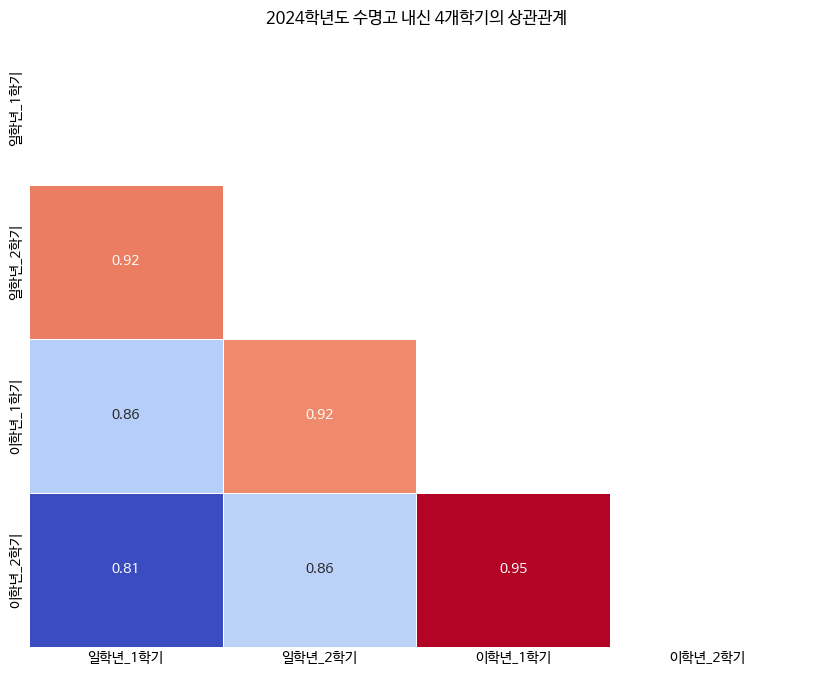

In [ ]:
#그래프 13: 내신과 수능과 상관관계(히트맵)


import seaborn as sns

#일부 항목추출
df_heatmap = df[['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']]


# 상관계수 계산
corr = df_heatmap.corr()


# 대각행렬 오른쪽 부분을 마스킹 (대각선을 포함한 오른쪽 상단 부분을 제외)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask, cbar=False)
plt.title('2024학년도 수명고 내신 4개학기의 상관관계')

# 축의 눈금(tick)만 삭제하고 label은 유지
plt.tick_params(axis='both', which='both', length=0)


plt.show()

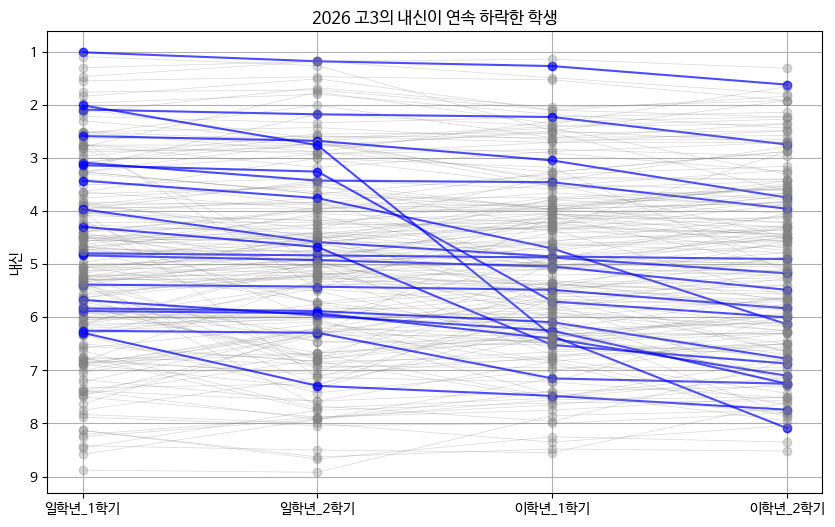

In [ ]:
#그래프 14: 내신이 계속 하락한 학생의 그래프

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 필요한 열만 추출 ('3학년_2학기' 제외)
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
df_selected = df[x_labels]



# X축 데이터 준비: 학기별 순서
x = x_labels

# 그래프 그리기
plt.figure(figsize=(10, 6))

# 각 학생별로 데이터를 시계열 형태로 플롯
for i, row in df_selected.iterrows():
    y = pd.to_numeric(row, errors='coerce').dropna().values  # NaN 값 제거 후 숫자형 변환

    # 점수가 연속으로 하락하는지 확인
    is_decreasing = all(np.diff(y) > 0)  # 연속으로 점수가 하락하면 True

    # 조건에 따라 컬러 또는 흑백으로 선 표시
    if is_decreasing:
        plt.plot(x[:len(y)], y, marker='o', linestyle='-', color='blue', alpha=0.7)  # 컬러 그래프
    else:
        plt.plot(x[:len(y)], y, marker='o', linestyle='-', color='gray', alpha=0.3, linewidth=0.5)  # 흑백 그래프

# Y축 반전
plt.gca().invert_yaxis()



plt.title("2026 고3의 내신이 연속 하락한 학생")
#plt.xlabel("학기")
plt.ylabel("내신")
plt.grid(True)
#plt.xticks(rotation=45)
plt.show()

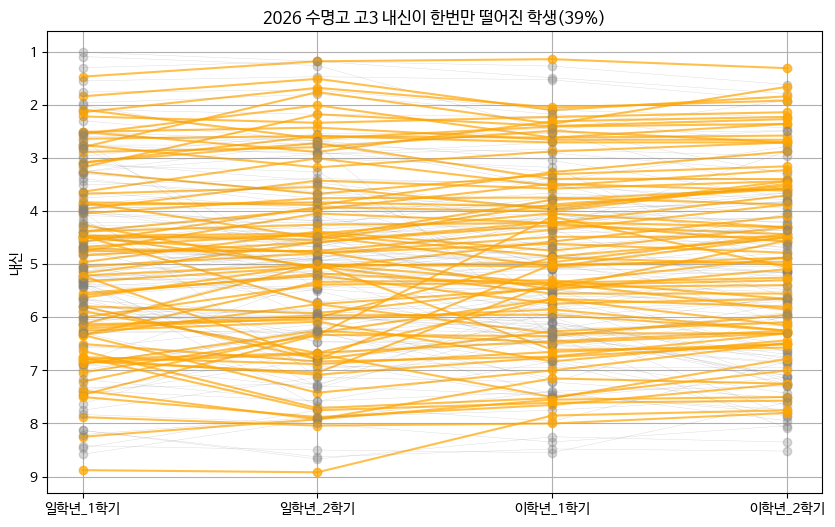

In [ ]:
#그래프 15: 내신이 한번만 하락한 학생


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




# 필요한 열만 추출 ('3학년_2학기' 제외)
x_labels = ['일학년_1학기', '일학년_2학기', '이학년_1학기', '이학년_2학기']
df_selected = df[x_labels]


count_one_decline = 0
total_students = len(df_selected)



# 그래프 그리기
plt.figure(figsize=(10, 6))

for i, row in df_selected.iterrows():
    y = pd.to_numeric(row, errors='coerce').dropna().values  # NaN 제거 후 숫자 변환
    semesters = x_labels[:len(y)]

    # 각 학기별 변화량 계산
    diffs = np.diff(y)  # 뒤에서 앞을 뺀 차이 (양수면 하락)

        # 조건 확인: 특정 구간(1-2, 2-1, 2-2)에서 딱 한 번만 하락
    # diffs[0]은 (1-1 → 1-2), diffs[1]은 (1-2 → 2-1), diffs[2]는 (2-1 → 2-2), diffs[3]은 (2-2 → 3-1)
    target_diffs = diffs[:]  # '1학년_1학기' ~ '3학년_1학기' 구간
    num_declines = np.sum(target_diffs > 0) # 뒤에서 앞을 뺀 차이 (양수면 하락)

    if num_declines == 1:
        count_one_decline += 1

    if num_declines == 1:
        plt.plot(semesters, y, marker='o', linestyle='-', color='orange', alpha=0.7)
    else:
        plt.plot(semesters, y, marker='o', linestyle='-', color='gray', alpha=0.3, linewidth=0.3)


# 비율 계산
ratio = count_one_decline / total_students * 100

# Y축 반전
plt.gca().invert_yaxis()

plt.title(f"2026 수명고 고3 내신이 한번만 떨어진 학생({ratio:.0f}%)")
plt.ylabel("내신")
plt.grid(True)
plt.show()

In [ ]:
df.columns

Index(['학년', '반', '번호', '이름', '석차', '석차백분율', '일학년_1학기', '일학년_2학기', '일학년_전학기',
       '이학년_1학기', '이학년_2학기', '이학년_전학기', '내신_4개학기'],
      dtype='object')

In [ ]:
#이름 열의 값이 최완서를 검색
df_choi = df[df['이름'] == '정하은']
df_choi

,학년,반,번호,이름,석차,석차백분율,일학년_1학기,일학년_2학기,일학년_전학기,이학년_1학기,이학년_2학기,이학년_전학기,내신_4개학기
8,3,2,30,정하은,9,4.62,1.96,1.79,1.88,2.17,2.43,2.3,2.09


In [ ]:
#'내신_4개학기' 열의 값의 랭크를 오름차순으로 10명 보여주기

df_rank = df[['이름', '내신_4개학기']].sort_values('내신_4개학기', ascending=True).head(10)
df_rank

,이름,내신_4개학기
0,최완서,1.26
1,정다경,1.27
2,김효원,1.43
3,정건하,1.61
4,오승화,1.67
5,한준우,1.81
6,심재원,1.94
7,김도담,1.94
8,정하은,2.09
9,조민석,2.14


In [ ]:
#Cursor에서 가져온 파일

from __future__ import annotations

from pathlib import Path
from typing import Optional

import pandas as pd


DATASET_PATH = Path("/content/drive/MyDrive/python/sumyeong/2026/nesin/nesin_4semesters_sumyeong2026_cleaning.xlsx")
OUTPUT_PATH = Path("/content/drive/MyDrive/python/sumyeong/2026/nesin/nesin_4semesters_sumyeong2026_with_parsed_id.xlsx")


def parse_student_code(value: object) -> tuple[Optional[int], Optional[str], Optional[str]]:
    """
    Parse student code format:
    30112 -> 3학년, 01반, 12번
    """
    if pd.isna(value):
        return None, None, None

    digits = "".join(ch for ch in str(value).strip() if ch.isdigit())
    if len(digits) != 5:
        return None, None, None

    grade = int(digits[0])
    class_no = digits[1:3]
    number = digits[3:5]
    return grade, class_no, number


def find_student_code_column(df: pd.DataFrame) -> str:
    # Prefer explicit column names first.
    candidates = ["학번", "학생코드", "학생번호", "student_id", "id", "code"]
    for col in candidates:
        if col in df.columns:
            return col

    # Fallback: find a column where most values look like 5-digit student code.
    best_col = None
    best_score = -1.0
    for col in df.columns:
        series = df[col].astype(str).str.replace(r"\D", "", regex=True)
        score = (series.str.len() == 5).mean()
        if score > best_score:
            best_col = col
            best_score = score

    if best_col is None:
        raise ValueError("학번으로 사용할 컬럼을 찾지 못했습니다.")
    return best_col


def main() -> None:
    if not DATASET_PATH.exists():
        raise FileNotFoundError(f"dataset 파일을 찾을 수 없습니다: {DATASET_PATH}")

    df = pd.read_excel(DATASET_PATH)
    student_col = find_student_code_column(df)

    parsed = df[student_col].apply(parse_student_code)
    df["학년"] = parsed.apply(lambda x: x[0])
    df["반"] = parsed.apply(lambda x: x[1])
    df["번호"] = parsed.apply(lambda x: x[2])

    df.to_excel(OUTPUT_PATH, index=False)
    print(f"dataset 사용 파일: {DATASET_PATH}")
    print(f"학번 컬럼: {student_col}")
    print(f"결과 저장: {OUTPUT_PATH}")


if __name__ == "__main__":
    main()


dataset 사용 파일: /content/drive/MyDrive/python/sumyeong/2026/nesin/nesin_4semesters_sumyeong2026_cleaning.xlsx
학번 컬럼: 학년
결과 저장: /content/drive/MyDrive/python/sumyeong/2026/nesin/nesin_4semesters_sumyeong2026_with_parsed_id.xlsx
